# 01 - Dataset Preview

Explore the 25-problem dataset used by the **Multi-LLM Collaborative Debate System**.

We look at the category breakdown, answer types, difficulty, and a few sample problems.

In [1]:
import sys, os
# Make the project root importable when running from the notebooks/ folder.
sys.path.append(os.path.abspath('..'))

import pandas as pd
from src.utils import load_problems
from src.config import DEFAULT_PROBLEMS_FILE

problems = load_problems(DEFAULT_PROBLEMS_FILE)
print(f'Loaded {len(problems)} problems from {DEFAULT_PROBLEMS_FILE}')

Loaded 25 problems from C:\Users\PCZONE.GE\Desktop\LLM Final\data\problems.jsonl


In [2]:
df = pd.DataFrame([p.model_dump() for p in problems])
df[['id', 'category', 'answer_type', 'difficulty', 'question']].head(25)

,id,category,answer_type,difficulty,question
0,math_001,mathematical_reasoning,integer,hard,In how many ways can you tile a 3x8 rectangle ...
1,math_002,mathematical_reasoning,integer,hard,How many trailing zeros are there in 100! (100...
2,math_003,mathematical_reasoning,integer,medium,How many positive divisors does the number 360...
3,math_004,mathematical_reasoning,integer,hard,What is the sum of all positive integers less ...
4,math_005,mathematical_reasoning,float,hard,"If you randomly shuffle the numbers 1,2,3,4 in..."
5,math_006,mathematical_reasoning,integer,medium,What is the last digit (units digit) of 7^100?
6,math_007,mathematical_reasoning,integer,medium,In how many ways can 8 non-attacking rooks be ...
7,math_008,mathematical_reasoning,integer,hard,What is the smallest positive integer that has...
8,phys_001,physics_science,float,hard,A uniform ladder leans against a frictionless ...
9,phys_002,physics_science,float,medium,A ball is thrown at 20 m/s at 30 degrees above...


## Category breakdown

Target split: 8 math, 6 physics, 7 logic/constraint, 4 game theory.

In [3]:
print('By category:')
print(df['category'].value_counts())
print('\nBy answer type:')
print(df['answer_type'].value_counts())
print('\nBy difficulty:')
print(df['difficulty'].value_counts())

By category:
category
mathematical_reasoning    8
logic_constraint          7
physics_science           6
game_theory               4
Name: count, dtype: int64

By answer type:
answer_type
integer            12
float               6
short_text          6
multiple_choice     1
Name: count, dtype: int64

By difficulty:
difficulty
hard      13
medium    10
easy       2
Name: count, dtype: int64


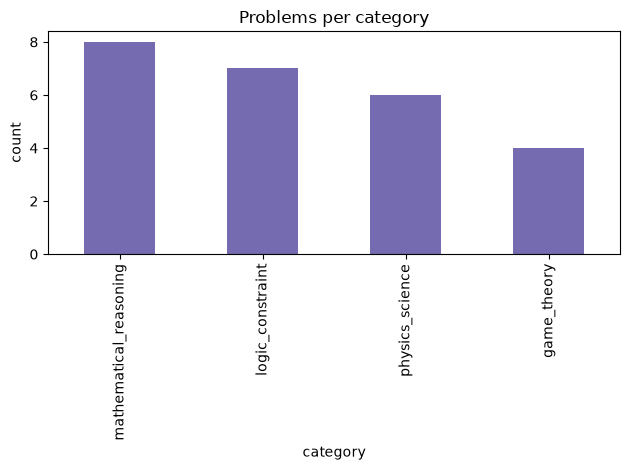

In [4]:
import matplotlib.pyplot as plt
df['category'].value_counts().plot(kind='bar', color='#756bb1')
plt.title('Problems per category')
plt.ylabel('count')
plt.tight_layout()
plt.show()

In [5]:
# Inspect one full problem, including the verifiable answer and notes.
import json
print(json.dumps(problems[0].model_dump(), indent=2))

{
  "id": "math_001",
  "category": "mathematical_reasoning",
  "question": "In how many ways can you tile a 3x8 rectangle with 2x1 dominoes?",
  "correct_answer": "153",
  "accepted_answers": [
    "153"
  ],
  "answer_type": "integer",
  "difficulty": "hard",
  "tolerance": null,
  "source_or_notes": "Classic domino tiling recurrence: f(n)=4f(n-2)-f(n-4)."
}
